# Interoperability: handing a mesh to PyVista, trimesh and Arrow

meshio++ reads ~41 formats into one `Mesh`. This notebook shows how to hand that
mesh straight to the tools you reach for next — **with no file round-trip**, and
with the numpy buffers *shared* rather than copied wherever the target accepts
them as they are:

- **PyVista** — `to_pyvista` / `from_pyvista`, for rendering and the VTK filter stack,
- **trimesh** — `to_trimesh` / `from_trimesh`, for triangle-mesh geometry processing,
- **Arrow / Parquet** — `to_arrow` / `write_parquet`, to get `point_data` /
  `cell_data` into pandas, polars or DuckDB.

These are Python-only optional extras (`pip install meshioplusplus[interop]`).
None of them reaches the C++/WebAssembly/C/Fortran core, which stays
dependency-free. See [`doc/interop.md`](../../doc/interop.md) for the full
mapping tables and the zero-copy contract.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')


def show(img, title=None, figsize=(9, 6)):
    """Embed a rendered RGB screenshot as a static image."""
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def render_grid(grid, title, scalars=None, cmap='viridis'):
    """Render a PyVista grid directly -- no conversion, no temporary file."""
    try:
        pl = pv.Plotter(off_screen=True, window_size=(1000, 720))
        if scalars is not None:
            pl.add_mesh(grid, scalars=scalars, cmap=cmap, show_edges=False,
                        scalar_bar_args={'title': scalars})
        else:
            pl.add_mesh(grid, color='#2ec4b6', show_edges=True,
                        edge_color='#1f4e79', line_width=0.2)
        pl.camera_position = 'iso'
        pl.add_axes()
        img = pl.screenshot(return_img=True)
        pl.close()
        show(img, title)
    except Exception as exc:  # pragma: no cover - head-less GL fallback
        print('PyVista render skipped:', exc)


print('pyvista  :', mp.has_pyvista())
print('trimesh  :', mp.has_trimesh())
print('pyarrow  :', mp.has_arrow())
print('open3d   :', mp.has_open3d(), '(Phase 2)')
print('dolfinx  :', mp.has_dolfinx(), '(Phase 2)')

pyvista  : True


trimesh  : True
pyarrow  : True
open3d   : False (Phase 2)
dolfinx  : False (Phase 2)


## Read the mesh

In [2]:
from collections import Counter

EXAMPLE = os.path.join(os.path.dirname(os.getcwd()), 'example.msh')
if not os.path.exists(EXAMPLE):
    EXAMPLE = os.path.join('..', 'example.msh')

mesh = mp.read(EXAMPLE)

# The bracket is stored as hundreds of small gmsh entity blocks, so summarize
# by cell type rather than printing every block.
totals = Counter()
for cb in mesh.cells:
    totals[cb.type] += len(cb.data)
print('meshio++     :', mp.__version__)
print('points       :', len(mesh.points))
print('cell blocks  :', len(mesh.cells))
print('cells by type:', dict(totals))
print('point data   :', sorted(mesh.point_data))
print('cell data    :', sorted(mesh.cell_data))


meshio++     : 9.25.0
points       : 52282
cell blocks  : 710
cells by type: {'vertex': 234, 'line': 4169, 'triangle': 58394, 'tetra': 235014}
point data   : ['gmsh:dim_tags']
cell data    : ['gmsh:geometrical']


## PyVista, without a temporary file

`to_pyvista` builds the VTK 9 `connectivity` / `offsets` / `celltypes` triple
from the mesh's blocks in order, so a **mixed-type** mesh — the normal case —
works directly. PyVista ships its own `from_meshio`, but it targets the upstream
`meshio` package and does not recognize `meshioplusplus`, which is why this
exists.

In [3]:
grid = mp.to_pyvista(mesh)
print(grid)

UnstructuredGrid (0x70d2c9df4ee0)
  N Cells:    297811
  N Points:   52282
  X Bounds:   -3.505e+00, 0.000e+00
  Y Bounds:   -3.185e+00, 6.250e-01
  Z Bounds:   0.000e+00, 3.820e-01
  N Arrays:   2


### The buffers really are shared

`np.shares_memory` is the check, not a claim in the docs. The points array and
every compatible data array are the *same memory* on both sides — writing
through one is visible in the other.

In [4]:
print('points   shared:', np.shares_memory(np.asarray(grid.points), mesh.points))

for name in list(mesh.point_data)[:3]:
    shared = np.shares_memory(np.asarray(grid.point_data[name]), mesh.point_data[name])
    print(f'point_data[{name!r}] shared:', shared)

# ... and the wrapper keeps the source arrays alive, which matters because
# meshio++'s readers hand back numpy owned by the C++ core.
print('references held by the grid:', len(grid._meshioplusplus_refs))

points   shared: True
point_data['gmsh:dim_tags'] shared: True
references held by the grid: 6


### `zero_copy_only=True` refuses to copy silently

Some conversions are unavoidable: VTK's `vtkIdType` is `int64` here, so `int32`
connectivity must be widened; a `wedge` block has to be reordered because
meshio's node order (the gmsh Prism) differs from VTK's; a 2-D mesh's points get
padded to three columns. With `zero_copy_only=True` each of those raises,
naming the array and the reason, instead of quietly costing you a copy.

VTK's `offsets`/`celltypes` and the cross-block concatenation are *derived*
arrays with no meshio++ counterpart, so they stay exempt — otherwise the flag
would reject every mixed-type mesh.

In [5]:
narrow = mp.Mesh(
    np.array([[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0]]),
    [('triangle', np.array([[0, 1, 2]], dtype=np.int32))],   # int32, not int64
)

try:
    mp.to_pyvista(narrow, zero_copy_only=True)
except ValueError as exc:
    print(exc)

meshio++: to_pyvista: connectivity cannot be shared with the target: connectivity dtype int32 is not int64 (VTK's vtkIdType)


### Render it

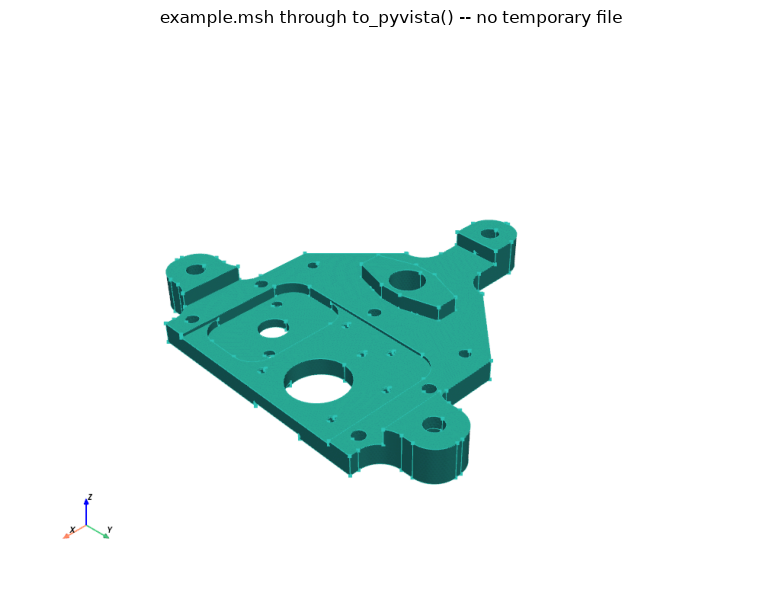

In [6]:
render_grid(grid, 'example.msh through to_pyvista() -- no temporary file')

Colour by anything meshio++ computed. `attach_quality` adds per-cell metrics as
`cell_data`, which `to_pyvista` concatenates block-major onto `grid.cell_data`.

cell_data: ['quality:aspect_ratio', 'quality:degenerate', 'quality:inverted', 'quality:max_angle', 'quality:max_dihedral', 'quality:min_angle', 'quality:min_dihedral', 'quality:scaled_jacobian', 'quality:skewness', 'quality:volume', 'quality:warpage']


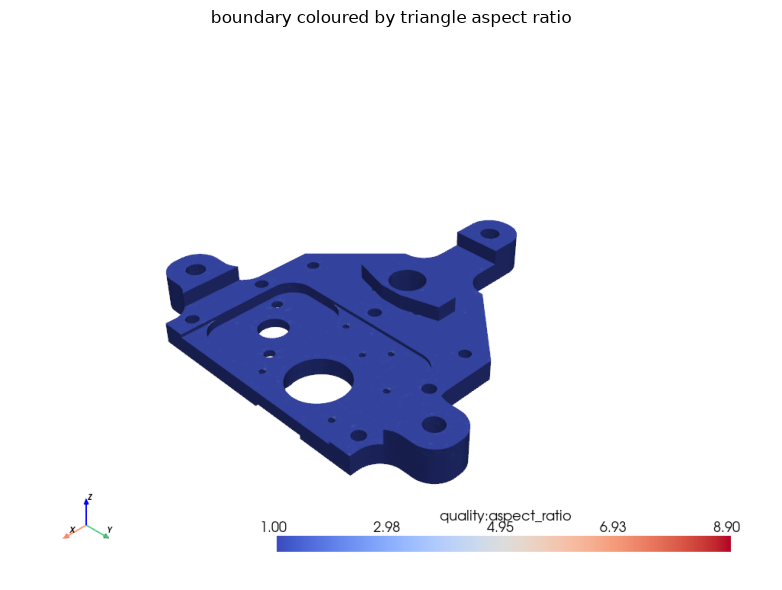

In [7]:
quality = mp.attach_quality(mp.extract_surface(mesh))
qgrid = mp.to_pyvista(quality)
print('cell_data:', sorted(qgrid.cell_data))
# Not every metric applies to every cell type -- scaled_jacobian, skewness and
# the dihedral angles are NaN on triangles -- so colour by one that is defined
# for them.
render_grid(qgrid, 'boundary coloured by triangle aspect ratio',
            scalars='quality:aspect_ratio', cmap='coolwarm')

### Regions survive the round-trip, tags and all

A named region becomes an int8 `region:<name>` mask array — directly colourable
in ParaView — plus a JSON sidecar in `grid.field_data` carrying each region's
`dim` and `tag`, which a mask alone cannot express. Without the sidecar a gmsh
physical group's integer tag would be lost on the way back.

`Side` regions are the one asymmetry: VTK has no `(cell, local facet)` concept,
so they are dropped with a warning naming them.

In [8]:
tagged = mp.Mesh(
    np.array([[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 1.0, 0.0], [0.0, 1.0, 0.0]]),
    [('triangle', np.array([[0, 1, 2], [0, 2, 3]], dtype=np.int64))],
    regions=[
        mp.Region('inlet', 'point', [0, 1], dim=0, tag=11),
        mp.Region('steel', 'cell', [1], dim=2, tag=7),
        mp.Region('wall', 'side', [[0, 1]], dim=1, tag=3),
    ],
)

tgrid = mp.to_pyvista(tagged)
print('mask arrays :', [k for k in tgrid.point_data] + [k for k in tgrid.cell_data])
print('sidecar     :', tgrid.field_data['meshioplusplus:regions'][0])

for region in mp.from_pyvista(tgrid).regions:
    print(region)

Warning: to_pyvista: side region 'wall' was dropped: the target has no (cell, local facet) concept

mask arrays : ['region:inlet', 'region:steel']
sidecar     : [{"name":"inlet","kind":"point","dim":0,"tag":11},{"name":"steel","kind":"cell","dim":2,"tag":7}]
<meshio++ Region 'inlet' kind=point dim=0 tag=11 entries=2>
<meshio++ Region 'steel' kind=cell dim=2 tag=7 entries=1>


## trimesh

trimesh holds **triangles only**, so `to_trimesh` routes anything else through
meshio++'s *own* operations rather than a reimplementation: volume meshes go
through `extract_surface`, higher-order cells through
`convert_cells('linearize')`, quads and polygons through
`convert_cells('simplexify')`. Each step is warned about, and `payload.ops`
records which ones ran.

In [9]:
if mp.has_trimesh():
    tm = mp.to_trimesh(mesh)
    print('vertices  :', tm.vertices.shape)
    print('faces     :', tm.faces.shape)
    print('watertight:', tm.is_watertight)
    print('volume    :', round(float(tm.volume), 6))
    # The composition that got us here:
    from meshioplusplus._interop import _to_triangles_payload
    print('ops       :', _to_triangles_payload(mesh).ops)
else:
    print('trimesh not installed: pip install meshioplusplus[trimesh]')

Warning: to_trimesh: the mesh has volume cells; its boundary was extracted (extract_surface drops cell_data and 
regions)

vertices  : (29151, 3)
faces     : (58394, 3)
watertight: True
volume    : 1.229946


ops       : ['extract_surface']


## Arrow and Parquet

`to_arrow` exports one data location as a `pyarrow.Table`, and `write_parquet`
writes it out for pandas / polars / DuckDB.

> **This is not a mesh format.** It exports *data arrays* for analytics and does
> not round-trip geometry, which is why it is deliberately absent from meshio++'s
> format registry — `meshioplusplus convert mesh.vtu out.parquet` does not work.

Two details worth knowing: a multi-component array becomes a single Arrow
`fixed_size_list` column rather than `v_0`/`v_1`/`v_2`, so the shape is not lost;
and the cell table's `cell` column is the **global block-major** cell index, the
same numbering regions and `partition_labels` use.

In [10]:
table = mp.to_arrow(mesh, location='point')
print(table.schema)

x: double
y: double
z: double
gmsh:dim_tags: fixed_size_list<item: int64>[2]
  child 0, item: int64
-- schema metadata --
meshioplusplus:version: '9.25.0'
meshioplusplus:location: 'point'
meshioplusplus:num_points: '52282'
meshioplusplus:num_cells: '297811'
meshioplusplus:cell_types: '[["vertex",1],["vertex",1],["vertex",1],["ver' + 9099
meshioplusplus:regions: '[]'


In [11]:
cells = mp.to_arrow(mesh, location='cell')
print(cells.schema.names)
print(cells.slice(0, 5).to_pydict())

# The mesh's counts, cell types and region names ride in the schema metadata,
# so the table is self-describing.
meta = {k.decode(): v.decode() for k, v in cells.schema.metadata.items()}
for key in ('meshioplusplus:version', 'meshioplusplus:location',
            'meshioplusplus:num_points', 'meshioplusplus:num_cells'):
    print(f'{key:34s}', meta[key])

['block', 'cell_type', 'cell', 'gmsh:geometrical']
{'block': [0, 1, 2, 3, 4], 'cell_type': ['vertex', 'vertex', 'vertex', 'vertex', 'vertex'], 'cell': [0, 1, 2, 3, 4], 'gmsh:geometrical': [1, 2, 3, 4, 5]}
meshioplusplus:version             9.25.0
meshioplusplus:location            cell
meshioplusplus:num_points          52282
meshioplusplus:num_cells           297811


In [12]:
import tempfile

path = os.path.join(tempfile.mkdtemp(), 'points.parquet')
mp.write_parquet(mesh, path, location='point')
print('wrote', os.path.getsize(path), 'bytes')

arrays, metadata = mp.read_parquet(path, return_metadata=True)
for name, values in list(arrays.items())[:5]:
    print(f'{name:24s} {str(values.dtype):10s} {values.shape}')

wrote 825055 bytes
x                        float64    (52282,)
y                        float64    (52282,)
z                        float64    (52282,)
gmsh:dim_tags            int64      (52282, 2)


The same thing from the command line, as a tenth verb in the `data` group:

```sh
meshioplusplus data export example.msh cells.parquet --location cell
```

(driven here through the CLI's entry point so the notebook does not depend on
where the console script was installed):

In [13]:
from meshioplusplus._cli import main

cli_out = os.path.join(tempfile.mkdtemp(), 'cells.parquet')
print('exit code:', main(['data', 'export', EXAMPLE, cli_out, '--location', 'cell']))
print('size     :', os.path.getsize(cli_out), 'bytes')


exported cell_data to /tmp/tmpxfg99r7l/cells.parquet
exit code: 0
size     : 1499156 bytes


Since v9.26.0 the frames come **directly** — `to_pandas` / `to_polars` sit on
the same table payload as `to_arrow`, with no pyarrow and no Parquet detour.
pandas columns are one-dimensional, so it is the one target that flattens a
multi-component array into suffixed columns (`v_0`/`v_1`/`v_2`), recording the
grouping in `df.attrs["meshioplusplus:components"]`; Arrow and polars keep the
shape natively. The Parquet file above remains the route when you want the data
*on disk*.

   block cell_type  cell  gmsh:geometrical
0      0    vertex     0                 1
1      1    vertex     1                 2
2      2    vertex     2                 3
3      3    vertex     3                 4
4      4    vertex     4                 5


Warning: to_pandas: column 'gmsh:dim_tags' was copied (pandas frames hold 1-D columns only; expanding to 
gmsh:dim_tags_0, gmsh:dim_tags_1 copies (to_arrow keeps the shape))

point columns : ['x', 'y', 'z', 'gmsh:dim_tags_0', 'gmsh:dim_tags_1']
components    : {"gmsh:dim_tags":["gmsh:dim_tags_0","gmsh:dim_tags_1"]}


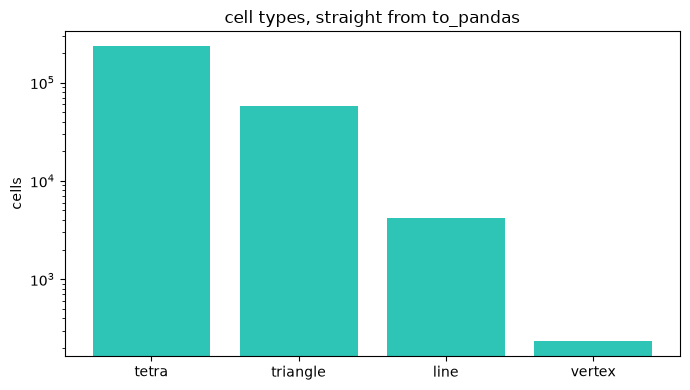

In [14]:
try:
    frame = mp.to_pandas(mesh, location='cell')   # no pyarrow, no file
    print(frame.head())

    points = mp.to_pandas(mesh, location='point')
    print('point columns :', list(points.columns))
    print('components    :', points.attrs['meshioplusplus:components'])

    counts = frame['cell_type'].value_counts()
    plt.figure(figsize=(7, 4))
    plt.bar(counts.index.astype(str), counts.values, color='#2ec4b6')
    plt.ylabel('cells')
    plt.title('cell types, straight from to_pandas')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('pandas not installed; skipping the DataFrame demo')

The polars counterpart keeps a multi-component array as a true `pl.Array`
column — no suffix rule needed — and deliberately takes no `zero_copy_only`:
polars always copies into its own Arrow-backed buffers, so the frame is
independent of the mesh by construction.

In [15]:
if mp.has_polars():
    pf = mp.to_polars(mesh, location='cell')
    print(pf.head())
    print(pf.schema)
else:
    print('polars not installed; skipping the polars demo')

shape: (5, 4)
┌───────┬───────────┬──────┬──────────────────┐
│ block ┆ cell_type ┆ cell ┆ gmsh:geometrical │
│ ---   ┆ ---       ┆ ---  ┆ ---              │
│ i32   ┆ str       ┆ i64  ┆ i32              │
╞═══════╪═══════════╪══════╪══════════════════╡
│ 0     ┆ vertex    ┆ 0    ┆ 1                │
│ 1     ┆ vertex    ┆ 1    ┆ 2                │
│ 2     ┆ vertex    ┆ 2    ┆ 3                │
│ 3     ┆ vertex    ┆ 3    ┆ 4                │
│ 4     ┆ vertex    ┆ 4    ┆ 5                │
└───────┴───────────┴──────┴──────────────────┘
Schema({'block': Int32, 'cell_type': String, 'cell': Int64, 'gmsh:geometrical': Int32})


## Machine learning: graphs, features, datasets

v9.27.0 closed the roadmap's ML section: `edge_index` exports the mesh as a
graph in the `(2, E)` layout PyTorch Geometric / DGL expect, `feature_matrix`
assembles a per-node feature matrix with a **recorded, versioned column
order**, `write_dataset` turns a set of meshes into one `mesh_id`-keyed
Parquet/zarr/HDF5 dataset, and `to_torch`/`to_jax` adopt the DLPack payload as
framework tensors. Here on a cropped piece of the bracket — first the node
graph itself, drawn from the actual `edge_index` output:

points: 3145  edges: 9435


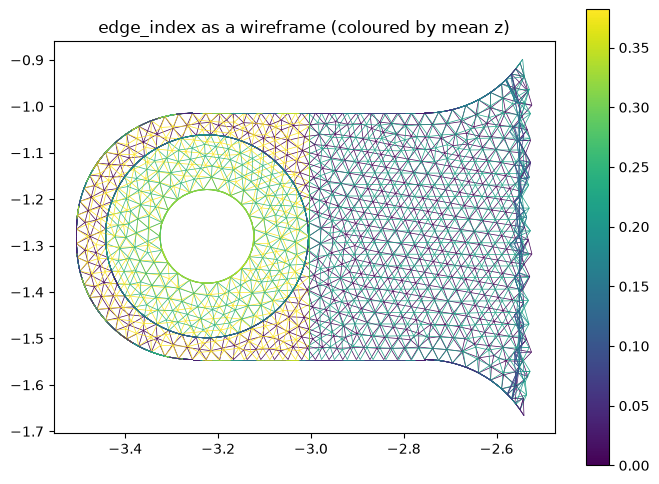

In [16]:
from matplotlib.collections import LineCollection

stats = mp.compute_stats(mesh)
lo, hi = np.array(stats['bbox_min']), np.array(stats['bbox_max'])
cut = lo + (hi - lo) * np.array([0.28, 1.0, 1.0])   # a slab of the bracket
piece = mp.extract_skin(mp.crop(mesh, bbox=(lo, cut)), linearize=True)

ei = mp.edge_index(piece, undirected=False)          # unique edges, (2, E)
print('points:', len(piece.points), ' edges:', ei.shape[1])

segs = piece.points[ei.T][:, :, :2]                  # x-y projection
depth = piece.points[ei.T][:, :, 2].mean(axis=1)     # colour by mean z
fig, ax = plt.subplots(figsize=(7, 6))
coll = LineCollection(segs, cmap='viridis', linewidths=0.5)
coll.set_array(depth)
ax.add_collection(coll)
ax.autoscale()
ax.set_aspect('equal')
ax.set_title('edge_index as a wireframe (coloured by mean z)')
fig.colorbar(coll, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

columns : ('x', 'y', 'z', 'gmsh:dim_tags_0', 'gmsh:dim_tags_1')
matrix  : (3145, 5) float64
schema  : feature_schema_version 1


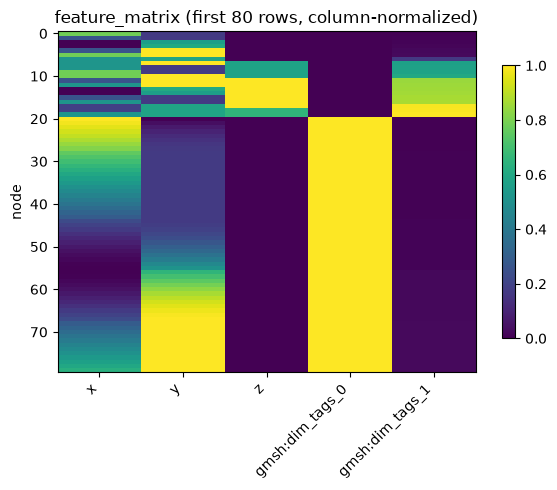

In [17]:
fm = mp.feature_matrix(piece, 'point')
print('columns :', fm.columns)
print('matrix  :', fm.matrix.shape, fm.matrix.dtype)
print('schema  : feature_schema_version', fm.schema['feature_schema_version'])

# The contract in action: normalize each column and look at the first rows.
X = fm.matrix[:80]
span = X.max(axis=0) - X.min(axis=0)
X = (X - X.min(axis=0)) / np.where(span > 0, span, 1.0)
plt.figure(figsize=(6, 5))
plt.imshow(X, aspect='auto', cmap='viridis')
plt.xticks(range(len(fm.columns)), fm.columns, rotation=45, ha='right')
plt.ylabel('node')
plt.title('feature_matrix (first 80 rows, column-normalized)')
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.show()

columns: ['x', 'y', 'z', 'gmsh:dim_tags']


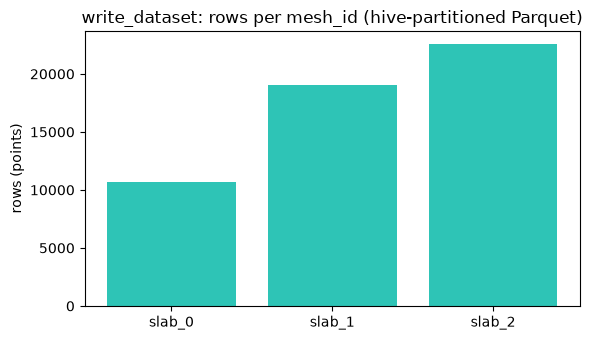

In [18]:
# A dataset: three slabs of the bracket -> one mesh_id-keyed Parquet dataset.
case_dir = tempfile.mkdtemp()
for i, x1 in enumerate((0.4, 0.7, 1.0)):
    x0 = x1 - 0.3 if i else 0.0
    slab = mp.crop(mesh, bbox=(lo + (hi - lo) * np.array([x0, 0, 0]),
                               lo + (hi - lo) * np.array([x1, 1, 1])))
    mp.write(os.path.join(case_dir, f'slab_{i}.vtu'), slab)

dataset_dir = os.path.join(case_dir, 'dataset')
manifest = mp.write_dataset(os.path.join(case_dir, 'slab_*.vtu'), dataset_dir)
print('columns:', manifest['columns'])

ids = [e['mesh_id'] for e in manifest['entries']]
rows = [e['num_rows'] for e in manifest['entries']]
plt.figure(figsize=(6, 3.5))
plt.bar(ids, rows, color='#2ec4b6')
plt.ylabel('rows (points)')
plt.title('write_dataset: rows per mesh_id (hive-partitioned Parquet)')
plt.tight_layout()
plt.show()

## Phase 2: Open3D and DOLFINx

Both slot into the same pure-payload seam, and both raise a clear
`NotImplementedError` naming the phase for now. The constraints are recorded in
[`doc/interop.md`](../../doc/interop.md): Open3D's `Vector3dVector` typically
*copies* (so the zero-copy contract differs per structure) and its wheel is
~400 MB; DOLFINx accepts single-cell-type meshes only, needs a `ufl`/`basix`
domain and an MPI communicator, requires a VTK→basix node-ordering permutation,
and is conda/apt-only so it can never be a pip extra.

In [19]:
try:
    mp._interop.to_open3d(mesh)
except NotImplementedError as exc:
    print(exc)

meshio++: to_open3d is Phase 2 and not implemented yet: Open3D's Vector3dVector typically copies, so the zero-copy contract differs per structure, and the wheel is ~400 MB. See doc/interop.md.
